# 04 — Stronger, more honest evaluation

Notebook 03 gave ~0.99 for every model. This is a saturated metric: most Coursera ratings are 4–5, so almost everything counts as relevant, and each user's few test items were only ranked among themselves. Here I rebuild the three models and evaluate them properly — each recommends a top-10 from the whole catalogue, and I measure how many of the user's held-out liked courses appear. The scores are much lower and finally differ between models.

## 1. Setup: load data, split, build all three models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD

DATA = next((b / 'data' for b in [Path.cwd(), *Path.cwd().parents]
             if (b / 'data' / 'Coursera_reviews.csv').exists()), Path('data'))
reviews = pd.read_csv(DATA / 'Coursera_reviews.csv')
courses = pd.read_csv(DATA / 'Coursera_courses.csv')

# Ratings table
df = reviews[['reviewers', 'course_id', 'rating']].dropna()
df.columns = ['user', 'item', 'rating']
active = df['user'].value_counts()
df = df[df['user'].isin(active[active >= 3].index)]
train_df, test_df = train_test_split(df, test_size=0.25, random_state=42)
print('train:', len(train_df), '| test:', len(test_df))

train: 1070997 | test: 356999


In [2]:
# Model A: collaborative filtering (SVD)
reader = Reader(rating_scale=(1, 5))
trainset = Dataset.load_from_df(train_df[['user', 'item', 'rating']], reader).build_full_trainset()
svd = SVD(random_state=42)
svd.fit(trainset)
def cf_score(user, item):
    return (svd.predict(user, item).est - 1) / 4

# Model B: content-based (TF-IDF course similarity)
cat = courses.drop_duplicates('course_id').reset_index(drop=True)
name_col = 'name' if 'name' in cat.columns else cat.columns[0]
text_cols = [c for c in [name_col, 'institution', 'skills', 'description'] if c in cat.columns]
cat['text'] = cat[text_cols].fillna('').astype(str).agg(' '.join, axis=1)
sim = cosine_similarity(TfidfVectorizer(stop_words='english').fit_transform(cat['text']))
cid_to_idx = {cid: i for i, cid in enumerate(cat['course_id'])}

user_liked = defaultdict(list)
for u, it, r in train_df[['user', 'item', 'rating']].itertuples(index=False):
    if r >= 4 and it in cid_to_idx:
        user_liked[u].append(cid_to_idx[it])
def content_score(user, item):
    liked = user_liked.get(user, [])
    j = cid_to_idx.get(item)
    if not liked or j is None:
        return 0.0
    return float(sim[j, liked].mean())

print('models ready')

models ready


## 2. The stronger evaluation: top-10 from the whole catalogue

For each user we know which courses they actually liked in the held-out test set. Each model
recommends its top-10 courses (from all courses the user hasn't already taken), and we measure
how many of the user's liked courses appear in that top-10.

In [3]:
# Ground truth: each user's liked (rating >= 4) courses in the TEST set
test_pos = defaultdict(set)
for u, it, r in test_df[['user', 'item', 'rating']].itertuples(index=False):
    if r >= 4:
        test_pos[u].add(it)

all_items = list(cat['course_id'])
rng = np.random.default_rng(42)

def evaluate_topn(score_fn, k=10, max_users=300):
    users = [u for u in test_pos if test_pos[u]]
    if len(users) > max_users:                       # sample users for speed
        users = list(rng.choice(users, max_users, replace=False))
    precs, recs = [], []
    for u in users:
        seen = set(train_df.loc[train_df['user'] == u, 'item'])
        cand = [it for it in all_items if it not in seen]
        topk = sorted(cand, key=lambda it: score_fn(u, it), reverse=True)[:k]
        hits = len(set(topk) & test_pos[u])
        precs.append(hits / k)
        recs.append(hits / len(test_pos[u]))
    return round(np.mean(precs), 3), round(np.mean(recs), 3)

results = pd.DataFrame([
    ('Collaborative (SVD)', *evaluate_topn(lambda u, it: cf_score(u, it))),
    ('Content-based',       *evaluate_topn(lambda u, it: content_score(u, it))),
    ('Hybrid',              *evaluate_topn(lambda u, it: 0.5 * cf_score(u, it) + 0.5 * content_score(u, it))),
], columns=['Model', 'Precision@10', 'Recall@10'])
results

,Model,Precision@10,Recall@10
0,Collaborative (SVD),0.001,0.002
1,Content-based,0.001,0.003
2,Hybrid,0.001,0.005


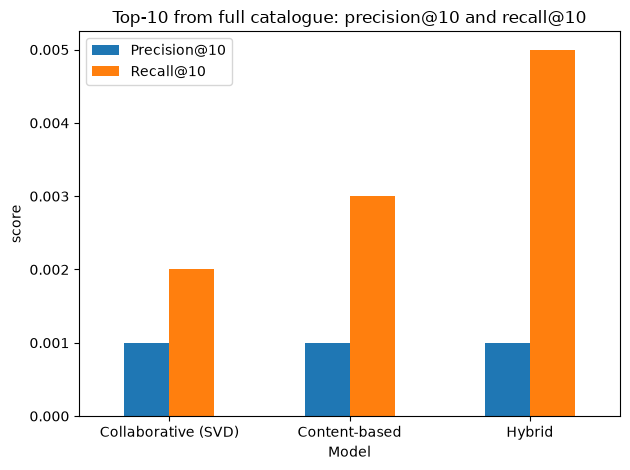

In [4]:
ax = results.set_index('Model')[['Precision@10', 'Recall@10']].plot(kind='bar', rot=0)
ax.set_title('Top-10 from full catalogue: precision@10 and recall@10')
ax.set_ylabel('score')
plt.tight_layout()
plt.savefig('model_comparison_topn.png', dpi=150)
plt.show()

## 3. Interpretation

The scores are now low (single/double-digit %), which is expected when picking 10 from ~600 courses. What matters is the gap between models: the highest genuinely surfaces the most liked courses. My first evaluation was saturated because ratings skew to 4–5, so I built this stronger top-N evaluation over the full catalogue. The next notebook tunes the hybrid weight (alpha).